In [1]:
import numpy as np

rng = np.random.default_rng(122807528840384100672342137672332424406)

from prod_fs import ProD

from matplotlib import rc
import matplotlib.pyplot as plt
plt.rcParams['font.serif'] = ['CMU Serif']
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['font.size'] = 11

In [2]:
# Initialize grids and example samples
# Class 1
class1 = rng.normal(loc=0.0, scale=0.2, size=3000)
class1mm_calcsd = np.std(class1, ddof=1)

# Class 2
class2 = rng.normal(loc=1.05*class1mm_calcsd, scale=0.2, size=3000)

# Class 3
class3 = rng.normal(loc=5.5*class1mm_calcsd, scale=0.2, size=3000)

# Concatenating all the clusters together
X = np.concatenate((class1, class2, class3))

# Initializing their label/class vector
y1 = np.repeat(1, 3000)
y2 = np.repeat(2, 3000)
y3 = np.repeat(3, 3000)
y = np.concatenate((y1, y2, y3))

X = X.reshape((len(X), 1))

In [3]:
# Carry out feature selection
prodRanker = ProD(k=2, lower_end=0.0, upper_end=1.0)
prodRanker.fit(X, y)

Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'


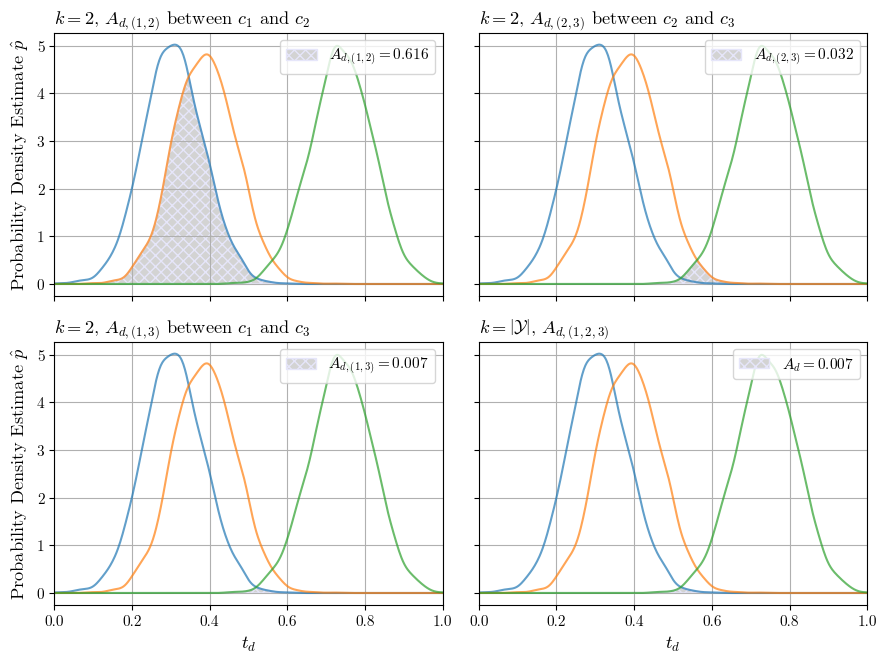

In [5]:
# Plot
plotlength = 9.0
fig, axs = plt.subplots(
    2, 2, sharex=True, sharey=True, figsize=(plotlength, plotlength/1.33)
)
prodRanker.plot_overlapAreas(
    0, _combinations=(1, 2), legend="intersection",
    legend_fIndex='d', _ax=axs[0,0]
)
axs[0,0].grid(visible=True, which="major", axis="both")
prodRanker.plot_overlapAreas(
    0, _combinations=(1, 3), legend="intersection",
    legend_fIndex='d', _ax=axs[1,0]
)
axs[1,0].grid(visible=True, which="major", axis="both")
prodRanker.plot_overlapAreas(
    0, _combinations=(2, 3), legend="intersection",
    legend_fIndex='d', _ax=axs[0,1]
)
axs[0,1].grid(visible=True, which="major", axis="both")
prodRanker.plot_overlapAreas(
    0, _combinations=None, legend="intersection",
    legend_fIndex='d', _ax=axs[1,1]
)
axs[1,1].grid(visible=True, which="major", axis="both")

# Legends
axs[0,0].legend(bbox_to_anchor=(1, 1), loc='upper right', fontsize="medium")
axs[0,1].legend(bbox_to_anchor=(1, 1), loc='upper right', fontsize="medium")
axs[1,0].legend(bbox_to_anchor=(1, 1), loc='upper right', fontsize="medium")
axs[1,1].legend(bbox_to_anchor=(1, 1), loc='upper right', fontsize="medium")

# x-limit
axs[1,0].set_xlim((0.0, 1.0))
axs[1,1].set_xlim((0.0, 1.0))

# x-ticks
axs[1,0].set_xticks(np.arange(0.0, 1.2, 0.2))
axs[1,1].set_xticks(np.arange(0.0, 1.2, 0.2))                    

# x-label
axs[0,0].set_xlabel("")
axs[0,1].set_xlabel("")
axs[1,0].set_xlabel(r"$t_d$")
axs[1,1].set_xlabel(r"$t_d$")

# y-label
axs[0,0].set_ylabel(r"Probability Density Estimate $\hat{p}$", fontsize="large")
axs[1,0].set_ylabel(r"Probability Density Estimate $\hat{p}$", fontsize="large")

# titles
axs[0,0].set_title(r"$k=2$, $A_{d,(1,2)}$ between $c_1$ and $c_2$", loc="left")
axs[0,1].set_title(r"$k=2$, $A_{d,(2,3)}$ between $c_2$ and $c_3$", loc="left")
axs[1,0].set_title(r"$k=2$, $A_{d,(1,3)}$ between $c_1$ and $c_3$", loc="left")
axs[1,1].set_title(r"$k=\left| \mathcal{Y} \right|$, $A_{d,(1,2,3)}$", loc="left")

fig.tight_layout()

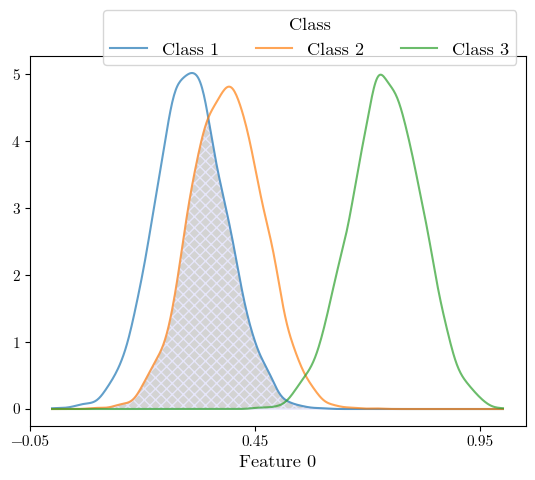

In [7]:
# Lazy way to get EPS of horizontal legend box
fig, ax = plt.subplots(1,1)
prodRanker.plot_overlapAreas(
    0, _combinations=(1, 2), legend="class", _ax=ax
)
ax.legend(
    ncols=3, bbox_to_anchor=(1, 1.15), loc="upper right", fontsize="large",
    title="Class", title_fontsize="large"
)